# Optimal Experimental Design DAE

To do parameter estimation, we use yeast growth model from previous [example](<../Simulation DAE>).
For OED we need a model and selected strategy for OED.

## Model creation

In [22]:
import mopeds
import numpy as np
import matplotlib.pyplot as plt

variable_list = mopeds.variables.VariableList()

variable_list.add_variable(mopeds.VariableState("x1", 5, 0, 10))
variable_list.add_variable(mopeds.VariableState("x2", 0.01))
variable_list.add_variable(mopeds.VariableAlgebraic("r", 1.7))
variable_list.add_variable(mopeds.VariableControlPiecewiseConstant("u1", 0.125, 0.05, 0.2))
variable_list.add_variable(mopeds.VariableControlPiecewiseConstant("u2", 5, 5, 35))

variable_list.add_variable(mopeds.VariableParameter("theta1", 0.310, 1e-2, 2))
variable_list.add_variable(mopeds.VariableParameter("theta2", 0.180, 1e-2, 20))
variable_list.add_variable(mopeds.VariableParameter("theta3", 0.550, 1e-2, 2))
variable_list.add_variable(mopeds.VariableParameter("theta4", 0.050, 1e-2, 2))

m = mopeds.Model(variable_list)

x1 = m.varlist_all["x1"].casadi_var
x2 = m.varlist_all["x2"].casadi_var
r = m.varlist_all["r"].casadi_var
u1 = m.varlist_all["u1"].casadi_var
u2 = m.varlist_all["u2"].casadi_var

theta1 = m.varlist_all["theta1"].casadi_var
theta2 = m.varlist_all["theta2"].casadi_var
theta3 = m.varlist_all["theta3"].casadi_var
theta4 = m.varlist_all["theta4"].casadi_var

eq_alg1 = r - (theta1 * x2 / (theta2 + x2))

eq1 = (r - u1 - theta4)  * x1
eq2 = - (r * x1 / theta3) + u1 * (u2 - x2)

m.add_equations_differential([eq1, eq2])
m.add_equations_algebraic([eq_alg1])

## Specifying OED problem

To allow OED change of state variables at time 0, state variable should be unfixed. Based on selected strategy, one needs to select different OED settings

In [23]:
oed_settings = mopeds.AdaptiveSampling()
oed_settings.max_time_experiment = 20
oed_settings.num_control_switches = 1
oed_settings.num_sampling_times = 10

variable_list["x1"].fixed = False
variable_list["u1"].fixed = False
variable_list["u1"].ignore_plotting = False
variable_list["u2"].fixed = False
variable_list["u2"].ignore_plotting = False

variable_list["theta1"].fixed = False

oed = mopeds.OptimalExperimentalDesign(m, [variable_list], settings=oed_settings)
oed.solver_settings["ipopt"]["max_iter"] = 40
res_oed = oed.optimize()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:       17
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       30
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       30
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        9
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        9
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0447170e+00 0.00e+00 1.08e+01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

## Result analysis

Plotting of the results of the OED is a complex tasks. Below there is an example, on how one can use optimized sampling and switching times to plot results. Depending on selected OED and sampling strategies one might need a different approach.

Blue points in a first graph show times, at which measurements have to be taken.

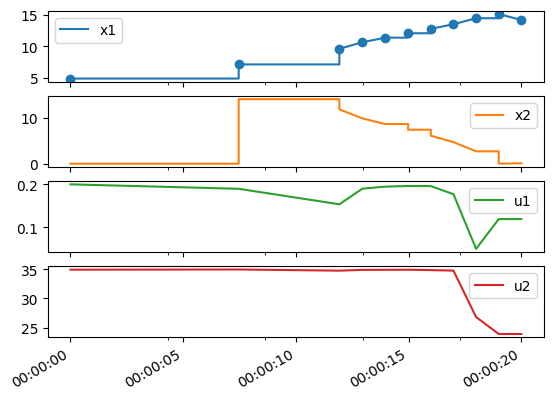

In [28]:
res_sim_oed = oed.generate_experimental_data(res_oed["x_dict"])
axis = res_sim_oed.plot(show=False)
axis[0].scatter(x=res_sim_oed["x1"].time_absolute, y=res_sim_oed["x1"].value)
plt.show()